In [98]:
from data.fashion import *
import numpy as np
import matplotlib.pyplot as plt
import math
from utils import mnist_reader
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

seed = 1234
np.random.seed(seed)


In [2]:
#Load Data
X_train, y_train = mnist_reader.load_mnist('data/fashion', kind='train')
X_test, y_test = mnist_reader.load_mnist('data/fashion',  kind='t10k')

print(f"Train Data: {X_train.shape}")
print(y_train.shape)

print(f"Test Data: {X_test.shape}")
print(y_test.shape)

Train Data: (60000, 784)
(60000,)
Test Data: (10000, 784)
(10000,)


In [3]:
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)
print(f"Train Set: {X_train_split.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Test Data: {X_test.shape}")

Train Set: (45000, 784)
Validation Set: (15000, 784)
Test Data: (10000, 784)


In [4]:
X_train_norm = X_train_split /255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

In [5]:
labels = ['T_Shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

In [68]:
def plot(cs, val_accuracies, train_accuracies, labels):
    plot_cs = cs 
    fig, axes = plt.subplots()
    axes.semilogx(plot_cs, train_accuracies, color='red', label='Training Accuracy')
    axes.semilogx(plot_cs, val_accuracies, color='blue', label='Validation Accuracy')
    axes.set_xticks(plot_cs)
    axes.set_xticklabels(labels)

    axes.set_xlabel('C (Regularization Strength)', fontsize=14)
    axes.set_ylabel('Accuracy', fontsize=14)
    axes.legend()
    plt.show()

In [69]:
def accuracy_vs_reg(X_train, y_train, X_val, y_val):
    train_accuracies = []
    validation_accuracies = []
    cs = [0.01, 0.1, 1, 10, 50]
    diff = []

    for c in cs:
        classifier = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, C=c)
        classifier.fit(X_train, y_train)

        pred_train = classifier.predict(X_train)
        pred_val = classifier.predict(X_val)
        train_acc = accuracy_score(y_train, pred_train)
        train_accuracies.append(train_acc)
        val_acc = accuracy_score(y_val, pred_val)
        validation_accuracies.append(val_acc)
        difference = train_acc-val_acc
        diff.append(difference)
    plot(cs, validation_accuracies, train_accuracies, ['0.01', '0.1', '1', '10', '50'])

    return train_accuracies, validation_accuracies, diff, cs

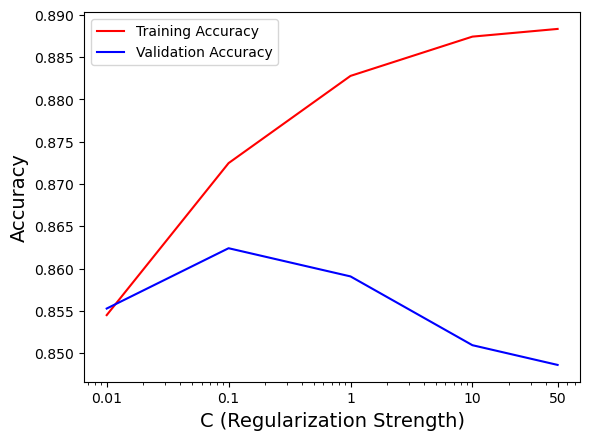

In [70]:
train_accuracies, validation_accuracies, diff, cs = accuracy_vs_reg(X_train_norm, y_train_split, X_val_norm, y_val)


In [71]:
best_idx = np.argmax(validation_accuracies)
best_c = cs[best_idx]

In [72]:
best_clf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, C=best_c, random_state=42)
best_clf.fit(X_train_norm, y_train_split)

test_acc = accuracy_score(y_test, best_clf.predict(X_test_norm))
print(f"Best C: {best_c}")
print(f"Train Accuracy: {train_accuracies[best_idx]:.4f}")
print(f"Validation Accuracy: {validation_accuracies[best_idx]}")
print(f"Final Test Accuracy: {test_acc:.4f}")


Best C: 0.1
Train Accuracy: 0.8725
Validation Accuracy: 0.8624
Final Test Accuracy: 0.8433


In [73]:
#C that overfits the most
overfit_idx = np.argmax(diff)
print(f"Most Overfit C: {cs[overfit_idx]}")
print(f"Train Accuracy: {train_accuracies[overfit_idx]:.4f}")
print(f"Validation Accuracy: {validation_accuracies[overfit_idx]}")
print(f"Difference: {diff[overfit_idx]:.4f}")

#C that underfits the most
underfit_idx = np.argmin(train_accuracies)
print(f"\nMost Underfit C: {cs[underfit_idx]}")
print(f"Train Accuracy: {train_accuracies[underfit_idx]:.4f}")
print(f"Validation Accuracy: {validation_accuracies[underfit_idx]:.4f}")
print(f"Difference: {diff[underfit_idx]:.4f}")


Most Overfit C: 50
Train Accuracy: 0.8883
Validation Accuracy: 0.8486
Difference: 0.0397

Most Underfit C: 0.01
Train Accuracy: 0.8545
Validation Accuracy: 0.8553
Difference: -0.0008


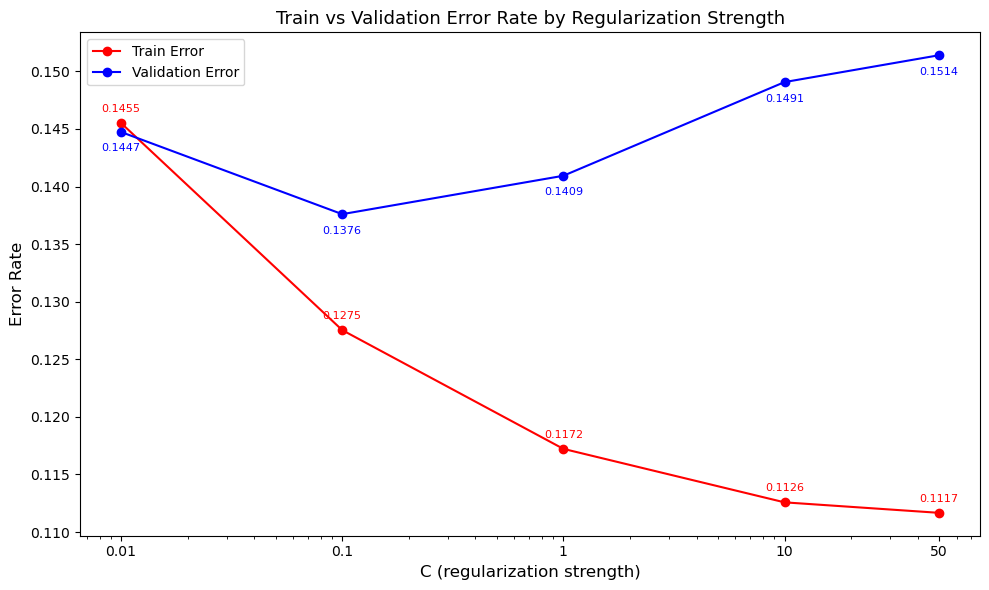

In [76]:
train_errors = []
val_errors = []

for i in range(len(train_accuracies)):
    train_errors.append(1-train_accuracies[i])
    val_errors.append(1-validation_accuracies[i])


fig, axes = plt.subplots(figsize=(10, 6))

axes.plot(cs, train_errors, color='red',  label='Train Error', marker='o')
axes.plot(cs, val_errors,   color='blue', label='Validation Error', marker='o')

# Add labels on each dot
for i in range(len(cs)):
    axes.annotate(f'{train_errors[i]:.4f}', (cs[i], train_errors[i]),
                  textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='red')
    axes.annotate(f'{val_errors[i]:.4f}', (cs[i], val_errors[i]),
                  textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8, color='blue')

axes.set_xscale('log')
axes.set_xticks(cs)
axes.set_xticklabels([str(c) for c in cs])
axes.set_xlabel('C (regularization strength)', fontsize=12)
axes.set_ylabel('Error Rate', fontsize=12)
axes.set_title('Train vs Validation Error Rate by Regularization Strength', fontsize=13)
axes.legend()
plt.tight_layout()
plt.show()

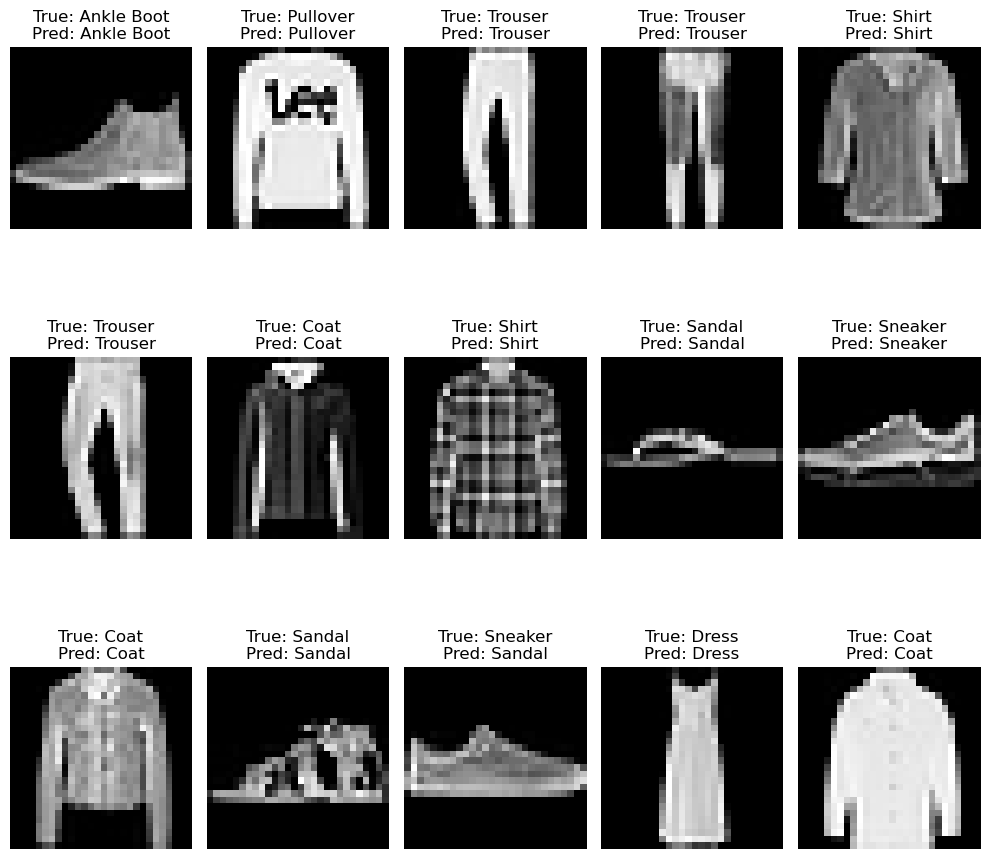

In [78]:
#Show set of images and how they were classified
preds = best_clf.predict(X_test_norm)
fig, axes = plt.subplots(3,5,figsize=(10,10))
axes = axes.flatten()

for i in range(15):
    axes[i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"True: {labels[y_test[i]]}\nPred: {labels[preds[i]]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

Number of misclassification: 1567


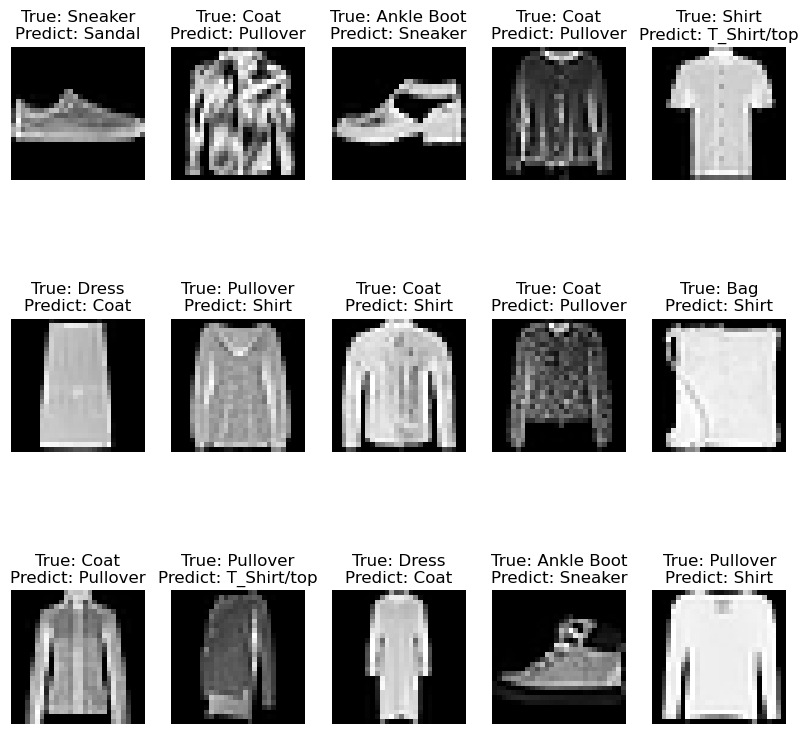

In [79]:
#Show set of images and how they were misclassified
preds = best_clf.predict(X_test_norm)
misclassified = np.where(preds != y_test)[0]
print("Number of misclassification:", len(misclassified))
fig, axes = plt.subplots(3,5,figsize=(10,10))
axes = axes.flatten()

for i,idx in enumerate(misclassified[:15]):
    axes[i].imshow(X_test[idx].reshape(28,28), cmap='gray')
    axes[i].set_title(f"True: {labels[y_test[idx]]}\nPredict: {labels[preds[idx]]}")
    axes[i].axis("off")
plt.show()


Most misclassified:  Shirt
Least misclassified: Trouser

T_Shirt/top: 186 misclassified
Trouser: 45 misclassified
Pullover: 267 misclassified
Dress: 132 misclassified
Coat: 238 misclassified
Sandal: 76 misclassified
Shirt: 436 misclassified
Sneaker: 67 misclassified
Bag: 60 misclassified
Ankle Boot: 60 misclassified


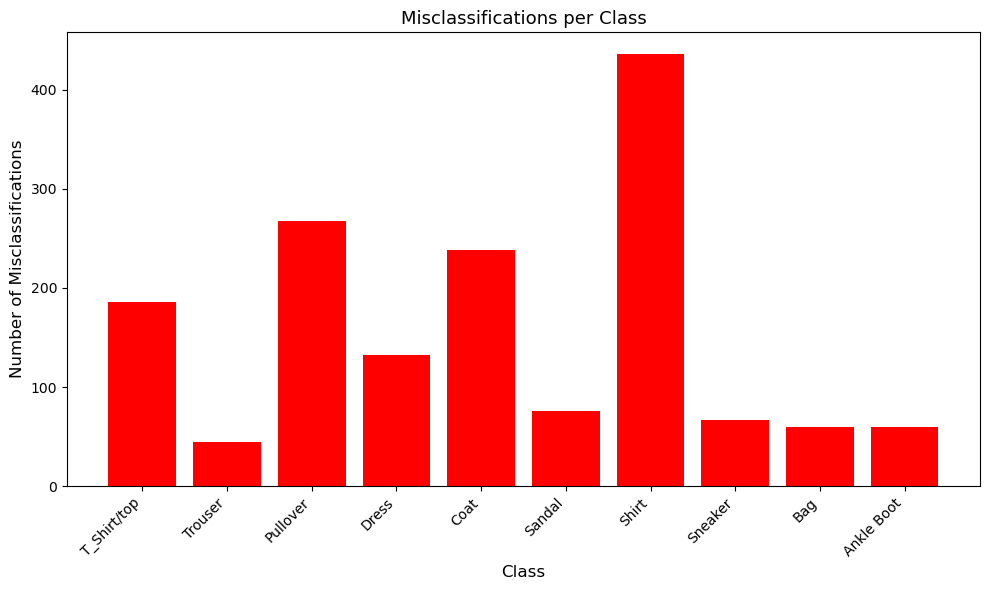

In [93]:
misclassified_per_class = []
for i in range(len(labels)):
    count = np.sum(y_test[misclassified] == i)
    misclassified_per_class.append(count)

most_idx  = np.argmax(misclassified_per_class)
least_idx = np.argmin(misclassified_per_class)
print(f"\nMost misclassified:  {labels[most_idx]}")
print(f"Least misclassified: {labels[least_idx]}\n")

for i, label in enumerate(labels):
    print(f"{label}: {misclassified_per_class[i]} misclassified")

fig, axes = plt.subplots(figsize=(10, 6))
axes.bar(labels, misclassified_per_class, color='red')
axes.set_xlabel('Class', fontsize=12)
axes.set_ylabel('Number of Misclassifications', fontsize=12)
axes.set_title('Misclassifications per Class', fontsize=13)
axes.set_xticks(range(len(labels)))
axes.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

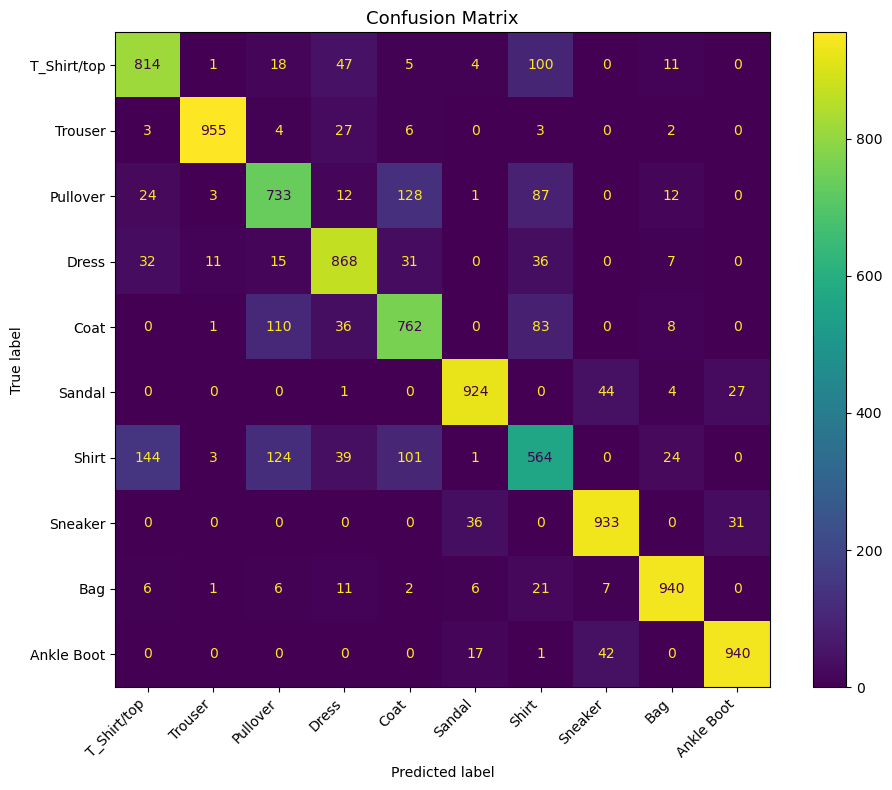

In [96]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()